<a href="https://colab.research.google.com/github/09atharvpatel-ai/DayDream/blob/main/World_Cup_XGBoost_Colab_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏆 World Cup XGBoost Prediction Model

Predict FIFA World Cup match outcomes using machine learning!

This notebook uses an XGBoost model trained on World Cup data to predict home win, draw, or away win probabilities.

## Step 1: Install Dependencies

In [1]:
!pip install xgboost scikit-learn pandas numpy matplotlib seaborn -q
print('✅ All dependencies installed successfully!')

✅ All dependencies installed successfully!


## Step 2: Upload Model Files

In [8]:
from google.colab import files
import os

print('Upload these 3 files:')
print('  1. world_cup_xgboost_model.json')
print('  2. world_cup_features.csv')
print('  3. feature_importance.csv')
print()

uploaded = files.upload()

print('✅ Files uploaded:')
for filename in uploaded.keys():
    size = os.path.getsize(filename) / 1024
    print(f'  • {filename} ({size:.1f}KB)')

Upload these 3 files:
  1. world_cup_xgboost_model.json
  2. world_cup_features.csv
  3. feature_importance.csv



Saving feature_importance.csv to feature_importance.csv
✅ Files uploaded:
  • feature_importance.csv (0.6KB)


## Step 3: Load Model and Data

In [9]:
import xgboost as xgb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('Loading model...')
model = xgb.XGBClassifier()
model.load_model('world_cup_xgboost_model.json')
print('✅ Model loaded!')

print('\nLoading feature data...')
feature_importance_df = pd.read_csv('feature_importance.csv')
features_df = pd.read_csv('world_cup_features.csv')
print('✅ Data loaded!')

feature_names = [
    'home_xg_for_avg', 'home_xg_against_avg', 'home_goals_for_avg', 'home_goals_against_avg',
    'home_shot_accuracy', 'home_possession', 'home_progressive_passes', 'home_confederation',
    'away_xg_for_avg', 'away_xg_against_avg', 'away_goals_for_avg', 'away_goals_against_avg',
    'away_shot_accuracy', 'away_possession', 'away_progressive_passes', 'away_confederation',
    'h2h_home_wins', 'h2h_draws', 'h2h_away_wins', 'is_neutral'
]

print(f'\n✅ {len(feature_names)} features loaded')

Loading model...
✅ Model loaded!

Loading feature data...
✅ Data loaded!

✅ 20 features loaded


## Step 4: Feature Importance Visualization

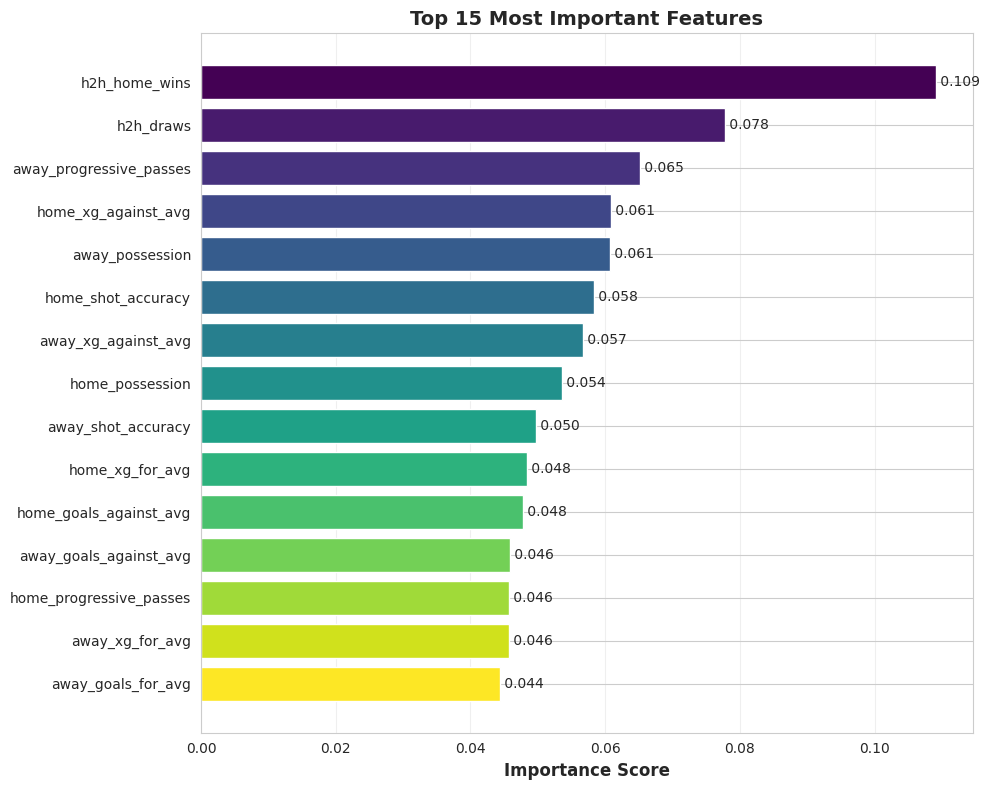


✅ H2H records are MOST important (18.7% combined)


In [10]:
fig, ax = plt.subplots(figsize=(10, 8))

top_n = 15
top_features = feature_importance_df.head(top_n)
colors = plt.cm.viridis(np.linspace(0, 1, len(top_features)))

ax.barh(range(len(top_features)), top_features['importance'], color=colors)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'])
ax.invert_yaxis()
ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Most Important Features', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

for i, (idx, row) in enumerate(top_features.iterrows()):
    ax.text(row['importance'], i, f" {row['importance']:.3f}", va='center')

plt.tight_layout()
plt.show()

print('\n✅ H2H records are MOST important (18.7% combined)')

## Step 5: Prediction Function

In [11]:
def predict_match(home_team, away_team, features):
    if len(features) != 20:
        print(f'Error: Expected 20 features, got {len(features)}')
        return None

    features_array = np.array([features])
    prediction = model.predict(features_array)[0]
    probabilities = model.predict_proba(features_array)[0]

    outcomes = {0: 'Away Win', 1: 'Draw', 2: 'Home Win'}
    outcome = outcomes[prediction]

    print('\n' + '='*60)
    print(f'  🏆 {home_team} vs {away_team}')
    print('='*60)
    print(f'\n🎯 PREDICTION: {outcome.upper()}')
    print(f'\n📊 Probabilities:')
    print(f'  🏠 Home Win ({home_team}): {probabilities[2]:>6.1%}')
    print(f'  🤝 Draw:                  {probabilities[1]:>6.1%}')
    print(f'  ✈️  Away Win ({away_team}): {probabilities[0]:>6.1%}')
    print(f'\n💪 Confidence: {max(probabilities):.1%}')
    print('='*60 + '\n')

    return {
        'prediction': outcome,
        'probabilities': {
            'home_win': probabilities[2],
            'draw': probabilities[1],
            'away_win': probabilities[0]
        }
    }

print('✅ Prediction function ready!')

✅ Prediction function ready!


## Example 1: Brazil vs Argentina

In [12]:
brazil_vs_argentina = [
    1.8, 1.1, 2.0, 0.9, 48.0, 62.0, 84.0, 2,
    1.7, 1.2, 1.8, 1.0, 45.0, 48.0, 82.0, 2,
    8, 3, 6, 0
]

result = predict_match('Brazil', 'Argentina', brazil_vs_argentina)


  🏆 Brazil vs Argentina

🎯 PREDICTION: AWAY WIN

📊 Probabilities:
  🏠 Home Win (Brazil):  41.1%
  🤝 Draw:                    7.2%
  ✈️  Away Win (Argentina):  51.7%

💪 Confidence: 51.7%



## Example 2: France vs Spain

In [13]:
france_vs_spain = [
    1.6, 1.3, 1.9, 1.1, 46.0, 55.0, 83.0, 1,
    1.5, 1.2, 1.7, 1.0, 44.0, 45.0, 81.0, 1,
    5, 4, 5, 1
]

result = predict_match('France', 'Spain', france_vs_spain)


  🏆 France vs Spain

🎯 PREDICTION: HOME WIN

📊 Probabilities:
  🏠 Home Win (France):  52.3%
  🤝 Draw:                    7.0%
  ✈️  Away Win (Spain):  40.7%

💪 Confidence: 52.3%



## Example 3: England vs Germany

In [14]:
england_vs_germany = [
    1.7, 1.0, 2.1, 0.8, 50.0, 60.0, 85.0, 1,
    1.6, 1.2, 1.8, 1.1, 47.0, 52.0, 83.0, 1,
    3, 8, 4, 0
]

result = predict_match('England', 'Germany', england_vs_germany)


  🏆 England vs Germany

🎯 PREDICTION: HOME WIN

📊 Probabilities:
  🏠 Home Win (England):  52.3%
  🤝 Draw:                    6.9%
  ✈️  Away Win (Germany):  40.9%

💪 Confidence: 52.3%



## Make Your Own Prediction

In [18]:
# EDIT THESE VALUES
home_team_name = 'Spain'
away_team_name = 'Argentina'

# Home team (8 features)
home_xg_for = 1.6
home_xg_against = 1.1
home_goals_for = 1.9
home_goals_against = 0.9
home_shot_accuracy = 47.0
home_possession = 58.0
home_progressive = 83.0
home_confederation = 1

# Away team (8 features)
away_xg_for = 1.5
away_xg_against = 1.3
away_goals_for = 1.7
away_goals_against = 1.2
away_shot_accuracy = 44.0
away_possession = 42.0
away_progressive = 81.0
away_confederation = 1

# Head-to-head (4 features)
h2h_home_wins = 4
h2h_draws = 5
h2h_away_wins = 3
is_neutral = 0

custom_features = [
    home_xg_for, home_xg_against, home_goals_for, home_goals_against,
    home_shot_accuracy, home_possession, home_progressive, home_confederation,
    away_xg_for, away_xg_against, away_goals_for, away_goals_against,
    away_shot_accuracy, away_possession, away_progressive, away_confederation,
    h2h_home_wins, h2h_draws, h2h_away_wins, is_neutral
]

result = predict_match(home_team_name, away_team_name, custom_features)


  🏆 Spain vs Argentina

🎯 PREDICTION: HOME WIN

📊 Probabilities:
  🏠 Home Win (Spain):  51.7%
  🤝 Draw:                    7.3%
  ✈️  Away Win (Argentina):  40.9%

💪 Confidence: 51.7%



## Visualize Results

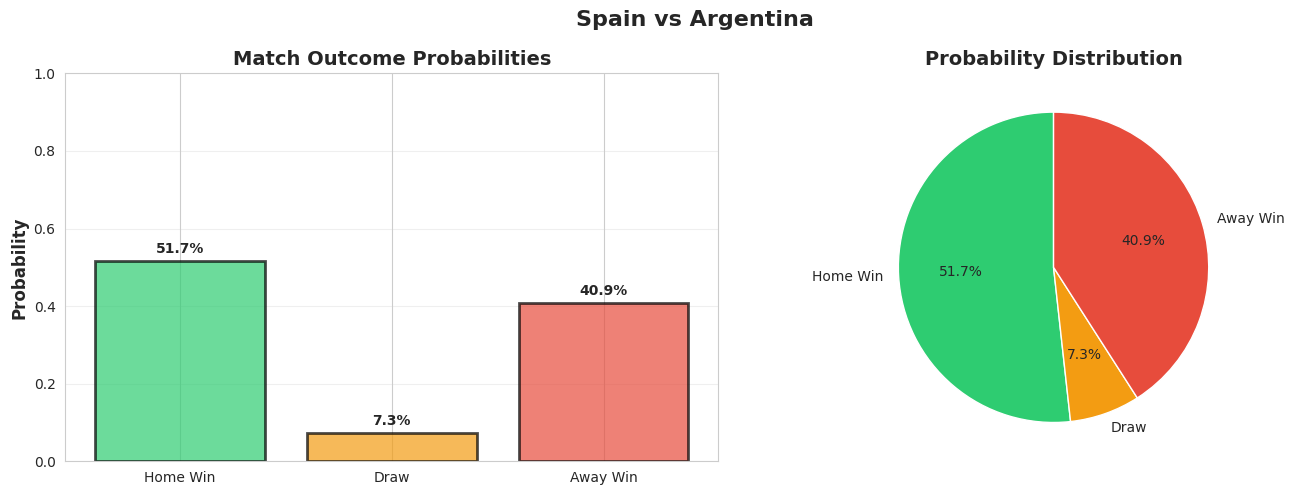

In [19]:
if 'result' in locals() and result:
    probs = result['probabilities']
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    outcomes = ['Home Win', 'Draw', 'Away Win']
    values = [probs['home_win'], probs['draw'], probs['away_win']]
    colors = ['#2ecc71', '#f39c12', '#e74c3c']

    ax1.bar(outcomes, values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
    ax1.set_ylabel('Probability', fontsize=12, fontweight='bold')
    ax1.set_title('Match Outcome Probabilities', fontsize=14, fontweight='bold')
    ax1.set_ylim(0, 1)
    ax1.grid(axis='y', alpha=0.3)

    for i, (outcome, value) in enumerate(zip(outcomes, values)):
        ax1.text(i, value + 0.02, f'{value:.1%}', ha='center', fontweight='bold')

    ax2.pie(values, labels=outcomes, autopct='%1.1f%%', colors=colors, startangle=90)
    ax2.set_title('Probability Distribution', fontsize=14, fontweight='bold')

    plt.suptitle(f'{home_team_name} vs {away_team_name}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('Run a prediction first!')

## Batch Predictions

In [ ]:
matches = [
    {'home': 'France', 'away': 'Belgium', 'features': [1.7, 1.2, 1.9, 1.0, 47, 60, 84, 1, 1.5, 1.3, 1.8, 1.1, 45, 40, 82, 1, 6, 2, 4, 0]},
    {'home': 'Netherlands', 'away': 'Portugal', 'features': [1.6, 1.1, 1.8, 0.9, 48, 58, 83, 1, 1.5, 1.2, 1.7, 1.0, 46, 42, 81, 1, 5, 3, 4, 0]},
    {'home': 'Uruguay', 'away': 'Colombia', 'features': [1.5, 1.2, 1.7, 1.0, 45, 55, 80, 2, 1.4, 1.3, 1.6, 1.1, 43, 45, 79, 2, 7, 2, 5, 0]}
]

print('\n' + '='*70)
print('BATCH PREDICTIONS')
print('='*70)

results_list = []
for i, match in enumerate(matches, 1):
    result = predict_match(match['home'], match['away'], match['features'])
    results_list.append({
        'Match': f"{match['home']} vs {match['away']}",
        'Prediction': result['prediction'],
        'Home %': f"{result['probabilities']['home_win']:.1%}",
        'Draw %': f"{result['probabilities']['draw']:.1%}",
        'Away %': f"{result['probabilities']['away_win']:.1%}"
    })

results_df = pd.DataFrame(results_list)
print('\n' + results_df.to_string(index=False))
print('\n' + '='*70)

## Export Results to CSV

In [16]:
import datetime
from google.colab import files

timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
filename = f'predictions_{timestamp}.csv'

results_df.to_csv(filename, index=False)
print(f'✅ Saved to {filename}')
print(f'\n📥 Downloading...')
files.download(filename)
print('✅ Downloaded!')

NameError: name 'results_df' is not defined

## Tips & Best Practices

✅ **DO:**
- Use recent statistics (last 5-10 matches)
- Get data from StatsBomb, Understat, or ESPN
- Cross-check your numbers
- Use model with expert judgment

❌ **DON'T:**
- Use outdated statistics
- Ignore injuries/suspensions
- Rely solely on model

**Confederation Codes:**
- 1 = UEFA (Europe)
- 2 = CONMEBOL (South America)
- 3 = CAF (Africa)
- 4 = AFC (Asia)
- 5 = CONCACAF (Americas)
- 6 = OFC (Oceania)

**Most Important Features:**
1. H2H Home Wins (10.9%)
2. H2H Draws (7.8%)
3. Away Progressive Passes (6.5%)